In [1]:
import polars as pl 

BKS = {
    "tsp": pl.read_csv("bks/tsp_bks.csv").with_columns(pl.concat_str(pl.col("instance"), pl.lit(".tsp")).alias("instance")),
    "csp": pl.read_csv("bks/csp_bks.csv"),
    "pdptw": pl.read_csv("bks/pdptw_bks.csv")
}

In [2]:
import orjson
from typing import Literal, Optional
from dataclasses import dataclass
from abc import abstractmethod, ABC
from functools import cached_property


@dataclass
class ObjOverTime:
    timestamps: list[float]
    objectives: list[float]
    steps: Optional[list[int]]

    def at(self, t: float):
        assert t >= 0
        # Dichotomic search across timestamps
        left, right = 0, len(self.timestamps) - 1
        if t > self.timestamps[-1]:
            return self.objectives[-1]
        while left < right:
            idx = (left + right) // 2
            if self.timestamps[idx] == t:
                return self.objectives[idx]
            if self.timestamps[idx] < t:
                left = idx + 1
            else:
                right = idx - 1
        return self.objectives[idx]

    @staticmethod
    def parse(sol_over_time: str):
        # Format [(t:0.423-v:361.000)-(t:0.424-v:360.000)]
        sol_over_time = sol_over_time.replace("(t:", '{"t":')
        sol_over_time = sol_over_time.replace("-step:", ',"step":')
        sol_over_time = sol_over_time.replace("-t:", ',"step":')
        sol_over_time = sol_over_time.replace("-v:", ',"v":')
        sol_over_time = sol_over_time.replace(")-", "},")
        sol_over_time = sol_over_time.replace(")]", "}]")
        data = orjson.loads(sol_over_time)
            
        # flatten to two lists instead of a list of objects
        timestamps = [point["t"] for point in data]
        if "step" in data[0]:
            steps = [int(point["step"]) for point in data]
        else:
            steps = None
        objectives = [point["v"] for point in data]
        return ObjOverTime(timestamps=timestamps, objectives=objectives, steps=steps)


@dataclass
class Result(ABC):
    problem: Literal["csp", "tsp", "pdptw"]
    instance: str
    oot: ObjOverTime

    @classmethod
    def parse(cls, row: dict):
        full_instance: str = row["instance"]
        _, problem, *_, instance = full_instance.split("/")
        assert problem in ("csp", "tsp", "pdptw")
        return cls(problem, instance, ObjOverTime.parse(row["solOverTime"]))

    @cached_property
    def bks(self) -> float:
        row = BKS[self.problem].filter(pl.col("instance") == self.instance).select("bks")
        if row.is_empty():
            return 0.0
        return row.item()

    @abstractmethod
    def is_feasible(self, t: float) -> bool:
        """Whether the solution is feasible or not at timestamp t."""

    def primal_gap(self, t: float):
        assert t >= 0.0
        if not self.is_feasible(t):
            return 1.0
        obj = self.objective(t)
        if obj == self.bks:
            return 0.0
        return abs(self.bks - obj) / max(abs(self.bks), abs(obj))
    
    def objective(self, t: float):
        return self.oot.at(t)


class CSPResult(Result):
    def is_feasible(self, t: float) -> bool:
        return self.objective(t) == 0


class PDPTWResult(Result):
    UNROUTED_NODE_PENALTY = 1000000000

    def is_feasible(self, t: float) -> bool:
        obj = self.oot.at(t)
        if obj is None:
            return False
        return obj < PDPTWResult.UNROUTED_NODE_PENALTY


class TSPResult(Result):
    UNROUTED_NODE_PENALTY = 1000000000

    def is_feasible(self, t: float) -> bool:
        obj = self.oot.at(t)
        if obj is None:
            return False
        return obj < TSPResult.UNROUTED_NODE_PENALTY

# Primal gap over time

In [3]:
import matplotlib.pyplot as plt
import numpy as np


def primal_gaps_over_time[R: Result](results: list[R], tmax: float):
    gaps = []
    for r in results:
        g = []
        for t in range(int(tmax) + 1):
            g.append(r.primal_gap(t))
        gaps.append(g)
    return np.array(gaps)


def objective_over_time(results: list[Result], tmax: float):
    objs = []
    for r in results:
        o = []
        for t in range(int(tmax) + 1):
            obj = r.oot.at(t)
            if obj is None:
                obj = float("inf")
            o.append(obj)
        objs.append(o)
    return np.array(objs)


def plot_by_bandit(df: pl.DataFrame, tmax: float):
    problem = df["instance"][0].split("/")[1]
    xs = np.arange(int(tmax) + 1)
    for name, bandit in df.group_by(pl.col("bandit")):
        match problem:
            case "csp":
                results = [CSPResult.parse(row) for row in bandit.iter_rows(named=True)]
            case "pdptw":
                results = [PDPTWResult.parse(row) for row in bandit.iter_rows(named=True)]
            case "tsp":
                results = [TSPResult.parse(row) for row in bandit.iter_rows(named=True)]
            case other:
                raise NotImplementedError(f"Not implemented for problem type: {other}")
        arr = primal_gaps_over_time(results, tmax)  # type: ignore
        mean, std = arr.mean(axis=0), arr.std(axis=0)
        ci95 = 1.96 * std / np.sqrt(arr.shape[0])
        plt.plot(xs, mean, label=name)
        plt.fill_between(xs, mean - ci95, mean + ci95, alpha=0.2)
        plt.xlabel("Time (s)")
        plt.ylabel("Primal gap")
        plt.margins(x=0.01, y=0.01)
    plt.legend()


# CSP

In [30]:
import polars as pl



df = pl.concat(
    [
        pl.read_csv("logs/epsilongreedy-r2-csp/results.csv").with_columns(bandit=pl.lit("epsilongreedy-mlg")),
        pl.read_csv("logs/ucb-r2-csp/results.csv").with_columns(bandit=pl.lit("ucb-mlg")),
        pl.read_csv("logs/random-r2-csp/results.csv").with_columns(bandit=pl.lit("random-mlg")),
        #pl.read_csv("logs/dqn-no-target-csp_100/results.csv"),
        #pl.read_csv("logs/dqn-csp_100/results.csv"),
        # pl.read_csv("logs/2025-10-07T18-02-59.655674/results.csv").with_columns(bandit=pl.lit("dqn-no-target-optimized-wrong-params")),
        pl.read_csv("logs/dqn-no-target-all/results.csv").with_columns(bandit=pl.lit("dqn-no-target-optimized")),
        pl.read_csv("logs/random-python/results.csv").with_columns(bandit=pl.lit("random-python")),
    ],
    how="align",
)
df = df.filter(pl.col("reward") == "r2")
df.height

3029

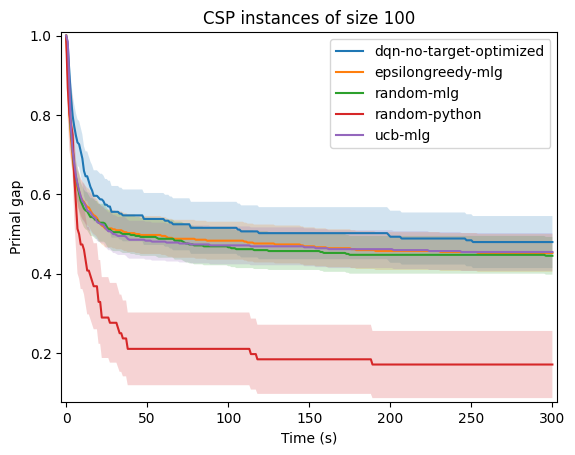

In [35]:
df_instances = df.filter(pl.col("instance").str.contains("csp_100"))
plot_by_bandit(df_instances, tmax=300)
plt.title("CSP instances of size 100")
plt.show()
    


#with open("examples/csp/testingall-100.txt") as f:
#    instances = [line.strip() for line in f.readlines()]
#df = df.filter(pl.col("instance").is_in(instances))    
#plot_by_bandit(df, tmax=300)
#plt.ylim(0.1, 0.5)

In [9]:
y_axis = "bestObj"
x_axis = "bandit"
for (label, *_), group in df.group_by(x_axis):
    print(f"{label}: mean={group[y_axis].mean()}, std={group[y_axis].std()}")

dqn-no-target-optimized: mean=0.3815028901734104, std=0.594650616829958
dqn-no-target-optimized-wrong-params: mean=0.37142857142857144, std=0.7443778346080286


dqn-no-target-optimized 0.3815028901734104
dqn-no-target-optimized-wrong-params 0.37142857142857144


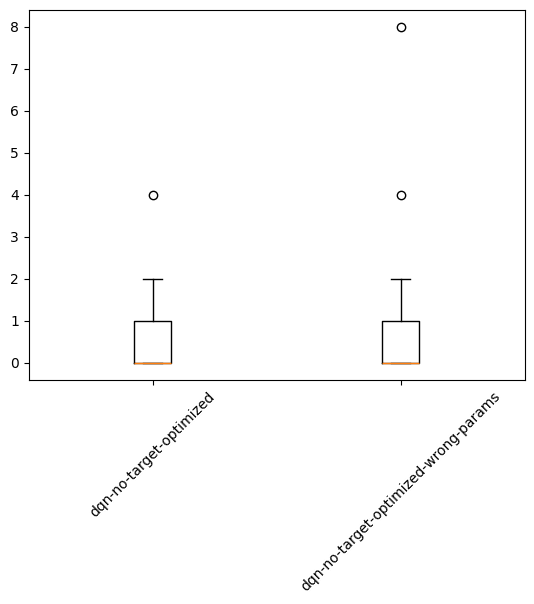

In [10]:
import matplotlib.pyplot as plt

col = "bestObj"
objs = []
labels = []
for (label, *_), group in df.group_by("bandit"):
    objs.append(group[col])
    labels.append(label)
    print(label, group[col].mean())
plt.boxplot(objs, tick_labels=labels)
# Rotate xticks by 45°
plt.xticks(rotation=45)
x=5

In [ ]:
to_concat = []
for path in filenames:
    df = pl.read_csv(path).filter((pl.col("bandit").is_in(reward_agnostic)) | (pl.col("reward") == reward))
    to_concat.append(df.select(pl.col("bandit"), pl.col("instance"), pl.col("solOverTime")))
df: pl.DataFrame = pl.concat(to_concat)

problem = df["instance"][0].split("/")[1]
xs = np.arange(int(tmax) + 1)
for name, bandit in df.group_by(pl.col("bandit")):
    match problem:
        case "csp":
            results = [CSPResult.parse(row) for row in bandit.iter_rows(named=True)]
        case "pdptw":
            results = [PDPTWResult.parse(row) for row in bandit.iter_rows(named=True)]
        case "tsp":
            results = [TSPResult.parse(row) for row in bandit.iter_rows(named=True)]
        case other:
            raise NotImplementedError(f"Not implemented for problem type: {other}")
    arr = primal_gaps_over_time(results, tmax)  # type: ignore
    mean, std = arr.mean(axis=0), arr.std(axis=0)
    ci95 = 1.96 * std / np.sqrt(arr.shape[0])
    plt.plot(xs, mean, label=name)
    plt.fill_between(xs, mean - ci95, mean + ci95, alpha=0.2)
    plt.xlabel("Time (s)")
    plt.ylabel("Primal gap")
    plt.margins(x=0.01, y=0.01)
    
    plt.legend()

## Analysis

In [6]:
import polars as pl
import os


def get_logs(directory: str):
    dfs = list[pl.DataFrame]()
    for file in os.listdir(directory):
        if not file.endswith("csv"):
            continue
        filename = os.path.join(directory, file)
        df = pl.read_csv(filename)
        if "loss" not in df.columns or "grad_norm" not in df.columns:
            df = df.with_columns(
                pl.lit(None, pl.Float32).alias("loss"),
                pl.lit(None, pl.Float32).alias("grad_norm"),
            )
        dfs.append(
            df.with_columns(
                (pl.col("timestamp_sec") - pl.col("timestamp_sec").min()).alias("t"),
                pl.col("loss").cast(pl.Float32),
                pl.col("grad_norm").cast(pl.Float32),
            )
        )
    return dfs


Text(0, 0.5, 'Loss')

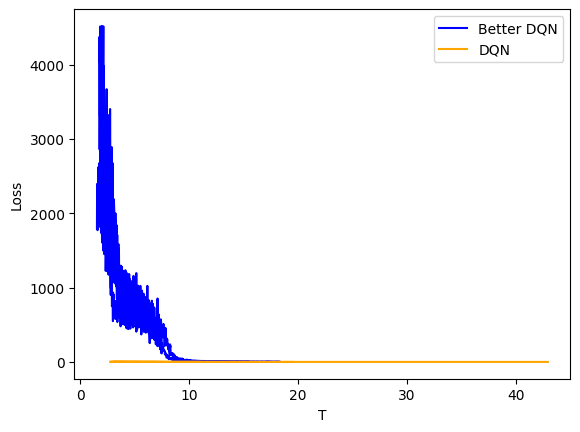

In [7]:
import matplotlib.pyplot as plt

x = "t"  # "t"
y = "loss"


for i, df in enumerate(get_logs("logs/2025-10-02T16-08-07.772033/csp-carseq_100_8_20_62/")):
    label = None
    if i == 0:
        label = "Better DQN"
    plt.plot(df[x], df[y], label=label, color="blue")
for i, df in enumerate(get_logs("logs/2025-10-03T09-00-02.784117/csp-carseq_100_8_20_62/")):
    label = None
    if i == 0:
        label = "DQN"
    plt.plot(df[x], df[y], label=label, color="orange")
    
plt.legend()
plt.xlabel(x.capitalize())
plt.ylabel(y.capitalize())

In [11]:
import polars as pl

INSTANCE = "carseq_100_8_20_62"
df = pl.read_csv("logs/2025-10-02T16-08-07.772033/results.csv").filter(pl.col("instance").str.contains(INSTANCE))
results_no_target = [CSPResult.parse(row) for row in df.iter_rows(named=True)]
df = pl.read_csv("logs/2025-10-03T09-00-02.784117/results.csv").filter(pl.col("instance").str.contains(INSTANCE))
results_target = [CSPResult.parse(row) for row in df.iter_rows(named=True)]

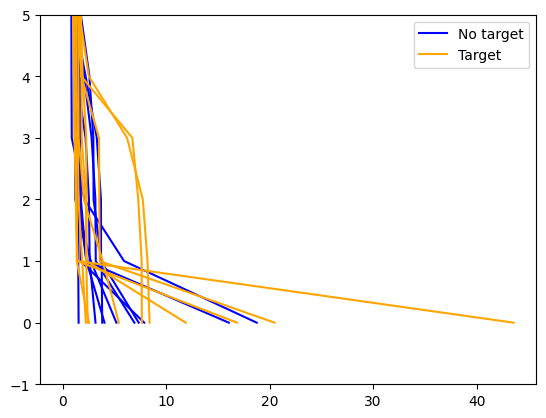

In [ ]:
import matplotlib.pyplot as plt

label = "No target"
for r in results_no_target:
    plt.plot(r.oot.timestamps, r.oot.objectives, color="blue", label=label)
    label = None

label = "Target"
for r in results_target:
    plt.plot(r.oot.timestamps, r.oot.objectives, color="orange", label=label)
    label = None
plt.ylim(-1, 5)
plt.legend()